In [22]:
import numpy as np
from time import time
# from numba import njit, prange

from matplotlib import text
from matplotlib import pyplot as plt, colors
import matplotlib
%matplotlib inline
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, InsetPosition, mark_inset
from scipy import ndimage
from matplotlib.colors import LogNorm
import glob
from collections import defaultdict
import json
import os
from scipy.optimize import curve_fit

In [2]:
def errbar(data):
    nsamp = 10
    nevery = int(data.shape[0] / nsamp)
    data_ = np.zeros(nsamp)
    for k in range(nsamp):
        data_[k] = data[k*nevery:(k+1)*nevery].mean()
    errbar_ = np.sqrt(data_.var()/(nsamp-1))
    return errbar_

In [3]:
def exclude_elements(arr2d, arr1d):
    # Create an empty list to hold the resulting rows
    result = []

    # Iterate over each row in the 2D array and corresponding element in the 1D array
    for row, exclude in zip(arr2d, arr1d):
        # Create a boolean mask where the condition is True for elements not equal to the element to exclude
        mask = row != exclude
        # Apply the mask to the row
        filtered_row = row[mask]
        # Append the filtered row to the result list
        result.append(filtered_row)
    
    # Convert the result list back to a numpy array
    return np.array(result)

In [20]:
# colors = ["red", "blue", "orange", "green", "cyan", "purple", "olive"]

In [5]:
plt.rcParams['font.family'] = 'Times New Roman'

matplotlib.rcParams['text.usetex'] = True
matplotlib.rcParams['text.latex.preamble'] = r'\usepackage{mathptmx}'

In [6]:
nO=432
nH=432*2

In [7]:
nbead = 1
nstep = 2001
natom = 432*3
traj_liq = np.zeros([nbead, nstep, natom, 6])
cell_liq = np.zeros([nbead, nstep, 3])
for ibead in range(nbead):
    with open(f"../scan/liq.classical/{ibead:02d}.xyz", "r") as f:
        for istep in range(nstep):
            for iline in range(5):
                f.readline()
            for iline in range(3):
                line = f.readline().split()
                cell_liq[ibead][istep][iline] = float(line[1]) - float(line[0])
            f.readline()
            for iline in range(natom):
                line = f.readline().split()
                traj_liq[ibead][istep][iline] = np.array(line[2:8], dtype=float)

In [8]:
typeO = np.arange(nO)
typeH = np.arange(nO, nO+nH)

In [9]:
coord_O = traj_liq[:, :, typeO, :3]
coord_H = traj_liq[:, :, typeH, :3]

In [10]:
O_bonded = ((typeH - nO)//2).astype(int)
O_all = np.tile(typeO, (nH, 1))
O_nonbonded = exclude_elements(O_all, O_bonded)

In [11]:
cell_liq.shape

(1, 2001, 3)

In [12]:
idx_frame = np.arange(200, 2000, 4)
nsamp_ = idx_frame.shape[0]

In [13]:
r_O2H_list = np.zeros([nsamp_, 1, nH, nO-1])
r_O2O1_list = np.zeros([nsamp_, 1, nH, nO-1])
beta_list = np.zeros([nsamp_, 1, nH, nO-1])

In [14]:
X_list = np.zeros([nsamp_, 1, nH, nO-1])
Y_list = np.zeros([nsamp_, 1, nH, nO-1])

In [33]:
# for isamp in range(traj_liq.shape[1]):
for iframe in range(len(idx_frame)):
    isamp = idx_frame[iframe]
    H = coord_H[:, isamp, :]
    O1 = coord_O[:, isamp, O_bonded, :]
    O2 = coord_O[:, isamp, O_nonbonded, :]
    prd = cell_liq[:, isamp]
    
    d_O2H = H[:, :, None, :] - O2
    d_O2H = (d_O2H/prd-np.floor(d_O2H/prd+0.5))*prd
    r_O2H = np.linalg.norm(d_O2H, axis=3)
    r_O2H_list[iframe] = r_O2H
    
    d_O2O1 = O1[:, :, None, :] - O2
    d_O2O1 = (d_O2O1/prd-np.floor(d_O2O1/prd+0.5))*prd
    
    d_HO1 = O1 - H
    d_HO1 = (d_HO1/prd-np.floor(d_HO1/prd+0.5))*prd
    
#     print(d_O2O1.shape)
#     print(d_HO1.shape)
    beta = np.arccos(np.sum(d_O2O1 * d_HO1[:, :, None, :], axis=-1) / np.linalg.norm(d_O2O1, axis=-1) / np.linalg.norm(d_HO1, axis=-1)[:, :, None]) / np.pi * 180
    beta_list[iframe] = beta
    
    n1 = np.cross(d_O2O1, d_O2H, axis=-1)
    n2 = np.cross(n1, d_O2O1, axis=-1)
    n2_norm = np.linalg.norm(n2, axis=-1)
    n2 = n2 / n2_norm[:, :, :, None]
    
# #     print(n2.shape)
    d_O2H_n2 = np.sum(d_O2H*n2, axis=-1) / np.linalg.norm(n2, axis=-1)
# #     print(np.where(d_O2H_n2 > 0))
# #     print(d_O2H_n2.shape)
# #     print(np.linalg.norm(n2, axis=-1))
    r_O2O1 = np.linalg.norm(d_O2O1, axis=3)
    r_O2O1_list[iframe] = r_O2O1    

# #     print(d_O2H.shape)
    X = np.sum(d_O2H * d_O2O1, axis=-1) / r_O2O1
# #     print(d_O2O1.shape)
    Y = d_O2H_n2

    X_list[iframe] = X
    Y_list[iframe] = Y


In [16]:
X = X_list.flatten()
Y = Y_list.flatten()

mask = (np.abs(X) < 3) & (np.abs(Y) < 0.6)
X = X[mask]
Y = Y[mask]

In [34]:
r_O2O1 = r_O2O1_list.flatten()
beta = beta_list.flatten()

mask = ((r_O2O1 > 2.5) & (r_O2O1 < 3.6) & (beta < 140))
r_O2O1 = r_O2O1[mask]
beta = beta[mask]

(0.0, 100.0)

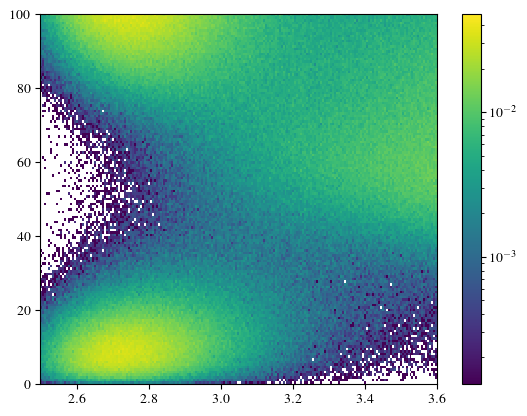

In [35]:
fig, ax = plt.subplots()
hh = ax.hist2d(r_O2O1.flatten(), beta.flatten(), density = True, bins=200, norm=colors.LogNorm())
fig.colorbar(hh[3], ax=ax)
ax.set_xlim(2.5, 3.6)
ax.set_ylim(0, 100)

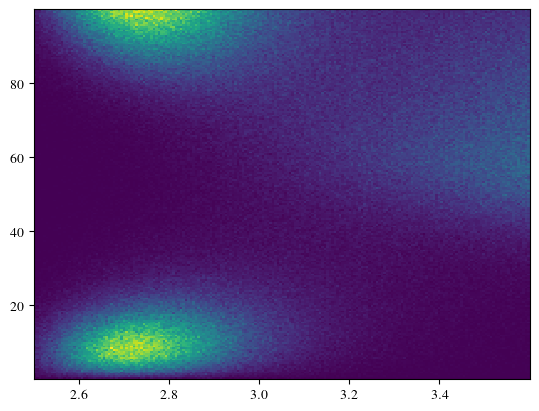

In [32]:
r_beta_dist = plt.hist2d(r_O2O1.flatten(), beta.flatten(), density = True, bins=200)

Text(0, 0.5, '$y/$\\AA')

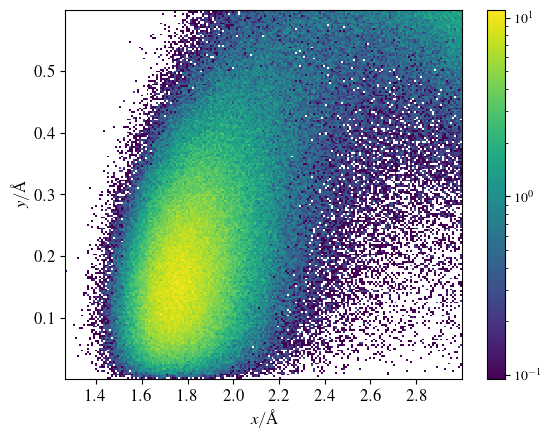

In [31]:
fig, ax = plt.subplots()
fig.
hh = plt.hist2d(X, Y, density = True, bins=200, norm=colors.LogNorm())
fig.colorbar(hh[3], ax=ax)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
ax.set_xlabel("$x/$\AA", fontsize=12)
ax.set_ylabel("$y/$\AA", fontsize=12)

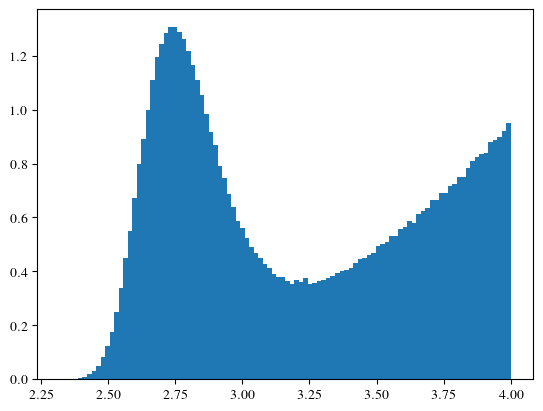

In [29]:
r_O2O1_dist = plt.hist(r_O2O1_list[r_O2O1_list < 4].flatten(), density=True, bins=100)
r_O2O1_dist_arg = r_O2O1_dist[1][1:] - 0.5*(r_O2O1_dist[1][1]-r_O2O1_dist[1][0])

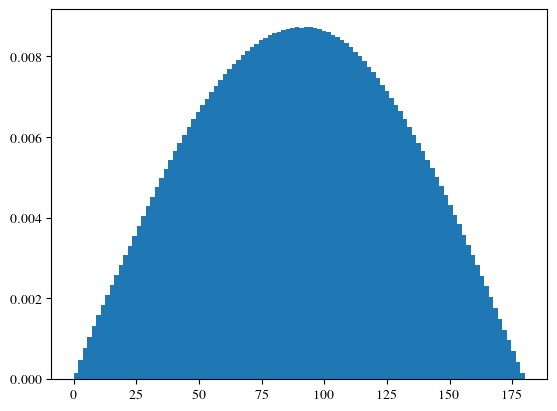

In [30]:
r_O2O1_dist = plt.hist(beta_list.flatten(), density=True, bins=100)
r_O2O1_dist_arg = r_O2O1_dist[1][1:] - 0.5*(r_O2O1_dist[1][1]-r_O2O1_dist[1][0])